In [1]:
import random
import h5py
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.preprocessing import StandardScaler
import math
import random

# User Input Desired Settings

In [2]:
# change file directory to the h5 file to convert
file = h5py.File('data/output_digi_HDF_Mg22_Ne20pp_8MeV.h5', 'r')

# The following will be needed to run later cells to align event ids


original_keys = list(file.keys())
original_length = len(original_keys)
#print(original_keys)

In [3]:
#making an array of the lengths of events
event_lens = np.zeros(original_length, int)
for i in range(original_length):
    event = original_keys[i]
    event_lens[i] = len(file[event])

In [4]:
sample_size = 512 #enter length of number of instances per event

# x[0] ,y[1] ,z[2] ,time[3], Amplitude[4], trackID (particle ID)[5], pointID[6]
# energy[7] ,energy loss[8] ,angle[9], Mass[10], Atomic number[11], Event_id index[12], number of tracks[13]

# Enter in the CLASSIFICATION and PROJECTIONS to evaluate in all caps as projection:
# B is BINARY, T is tertiary, and FOUR is four track classiification
CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'

PROJ_TO_COLS = {'XYZ': [0,1,2]}

user_input = PROJ_TO_COLS[PROJECTION]
print(class_type)
print(user_input)

BINARY
[0, 1, 2]


# Convert Raw H5 File into npArray with Corresponding key index

In [5]:
#making an array of the events data-- [event #, instance, data value]
#length of each event is based on the longest event in dataset
#12th index now corresponds to index of event id in original_keys
# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index
file_name = ISOTOPE + '_w_key_index'
event_data = np.zeros((original_length, np.max(event_lens), 13), float) 
for n in tqdm.tqdm(range(original_length)):
    name = original_keys[n]
    event = file[name]
    ev_len = len(event)
    #converting event into an array
    for i,e in enumerate(event):
        instant = np.array(list(e))
        event_data[n][i][:12] = np.array(instant)
        event_data[n][i][-1] = float(n) #insert index value to find corresponding event ID
np.save('data/' + file_name, event_data)

100%|██████████| 10000/10000 [05:51<00:00, 28.43it/s]


### Assertion Statements to Check the Conversion

In [6]:
data = np.load( 'data/' + ISOTOPE + '_w_key_index' + '.npy')

assert data.shape == (original_length, np.max(event_lens), 13), 'Array has incorrect shape'
assert len(np.unique(data[:,:,12])) == original_length, 'Array has incorrect Event_ids'

# Random sample From New Numpy Array

In [7]:
#NOT completely random sampling!
#13th index now corresponds to the number of tracks in event, 0 = beam, 1= two track, 2 = 3 track...

# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index, number of tracks


data_array = ISOTOPE + '_w_key_index.npy' #insert desired array to sample from 
new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('data/' + data_array)
new_data = np.zeros((original_length, sample_size, 14), float) 
for i in tqdm.tqdm(range(original_length)):
    ev_len = event_lens[i]    #length of event-- i.e. number of instances
    particle_ids = data[i][:ev_len,5]
    label, distr = np.unique(particle_ids, return_counts=True)
    shortest = label[np.argmin(distr)]
    shortest_ind = np.argwhere(particle_ids == shortest)
    if ev_len == sample_size:    #if array is already preferred length
        new_data[i][:,:-1] = data[i][:ev_len,:]
    else:
        instant = 0
        for n in range(shortest_ind.size):    #the first instances sampled will be those belonging to the shortest track
            new_data[i,instant,:-1] = data[i,shortest_ind[n],:]
            instant += 1
        need = sample_size - shortest_ind.size
        random_points = np.random.choice(range(ev_len), need, replace= True if need > ev_len else False)  #choosing the random instances to sample
        for r in random_points:
            new_data[i,instant,:-1] = data[i,r,:] 
            instant += 1
    unique_point_ids = np.unique(data[i,:ev_len,5])    #array of unique particle IDs
    new_data[i][0][-1] = unique_point_ids.size - 1    #number of unique particles, scaled to start at 0
np.save('data/' + new_array_name, new_data)#creating new dataset within the h5 file for the event
    

100%|██████████| 10000/10000 [00:09<00:00, 1035.48it/s]


### Assertion Statements to Check the Data After Random Sampling

In [8]:
data = np.load( 'data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')

assert data.shape == (original_length, sample_size, 14), 'Array has incorrect shape'
assert len(np.unique(data[:,:,13])) == len(np.unique(data[:,:,5]))-1, 'Array has incorrect number of tracks'

# Check Distribution of labels after sampling

In [9]:
#cheking how the distribution of labels changes from sampling

name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('data/' + name + '.npy')
real_tracks = np.zeros(original_length,int) 
sampled_tracks = np.zeros(original_length,int)

for i in range(original_length):
    ev_nt = data[i]
    real_tracks[i] = ev_nt[0,-1]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    sampled_tracks[i] = unique_point_ids.size - 1
    
label1, og_distr = np.unique(real_tracks, return_counts=True)
label2, new_distr = np.unique(sampled_tracks, return_counts=True)
print(og_distr)
print(label1)
print(new_distr)
print(label2)
print('Events changed = ' + str(np.sum(np.abs(new_distr - og_distr))//2))

[5002  104 2554 2319   16    5]
[0 1 2 3 4 5]
[5002  105 2554 2318   16    5]
[0 1 2 3 4 5]
Events changed = 1


# Binary, Tertiary, and Other Classification

In [10]:
#OLD #Necessary only if need labels to be ints. If the case, then make another category for 'Other' classification

#a binary function, with particle 0 being the alpha
#if CLASSIFICATION == 'BINARY':
#    def alpha(p):
#        if int(p) == 0:
#            return 0
#        else:
#            return 1
#elif CLASSIFICATION == 'TERTIARY':
#    def alpha(p):
#            if int(p) == 0:
#                return 0
#            elif int(p) == 1:
#                return 1
#            else:
#                return 2

In [11]:
#OLD #Necessary?

# Making the labels binary
#if CLASSIFICATION == 'BINARY' or CLASSIFICATION == 'TERTIARY':
#    name = ISOTOPE + '_4-track_size' + str(sample_size)
#    data = np.load('data/' + name + '.npy')
#    new_classification = np.zeros((len(data), sample_size, 14), float)
#    for i in tqdm.tqdm(range(len(data))):
#        event = data[i]
#        new_event = event[:,:]
#        new_event[:,5] = list(map(alpha, event[:,5]))
#        new_classification[i,:,:] = new_event[:,:]
#np.save('data/' + name, new_classification)

# Split Testing Set, Training Set, and Validation Set

## Split Training and Testing Sets

In [12]:
# performs a 20-test 20-val 60-train split on all 4-track events
# generates an array of numbers as long as the length of the data to randomize the events 

In [13]:
name = ISOTOPE + '_size' + str(sample_size)
all_events = np.load('data/' + name + '_sampled.npy')
rand_shuffle = np.random.choice(len(all_events), len(all_events), replace = False)


# 20-20 marking for test and validation
test_split = int(len(all_events) * .2)
val_split = int(len(all_events) * .4)


test_data =  all_events[rand_shuffle[:test_split],:,:]    #only saving the indices and number of tracks of the test events
val_data = all_events[rand_shuffle[test_split:val_split],:,:]
train_data = all_events[rand_shuffle[val_split:],:,:]


print(test_data.shape, val_data.shape, train_data.shape)
np.save('data/' + ISOTOPE + '_' + str(sample_size) + 'test', test_data)
np.save('data/' + ISOTOPE + '_' + str(sample_size) + 'train', train_data)
np.save('data/' + ISOTOPE + '_' + str(sample_size) + 'val', val_data)

(2000, 512, 14) (2000, 512, 14) (6000, 512, 14)


# Making Test Sets

In [14]:
prev_data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')
tr = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'train.npy')
va = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'val.npy')
te = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'test.npy')

#works perfect if length of dataset is even, if odd, rounding may be off
assert tr.shape == (np.ceil(len(prev_data) * .6) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
assert va.shape == (np.ceil(len(prev_data) * .2) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
assert te.shape == (np.ceil(len(prev_data) * .2) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
print(len(prev_data))
print(tr.shape, va.shape, te.shape)
print(len(np.unique(tr[:,:,5])))

10000
(6000, 512, 14) (2000, 512, 14) (2000, 512, 14)
7


## Checking Test, Training, and Validation

In [15]:
#OLD
check = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'train.npy')
check2 = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'val.npy')
check3 = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'test.npy')


print(check.shape)
print(check2.shape)
print(check3.shape)
print('')

print(check[1][0][:])
print('')

print(len(np.unique(check[:,:,12])))
print(len(np.unique(check2[:,:,12])))
print(len(np.unique(check3[:,:,12])))

(6000, 512, 14)
(2000, 512, 14)
(2000, 512, 14)

[7.85317764e+01 1.64392578e+02 4.20800000e+02 1.69000000e+02
 6.21662230e+00 4.00000000e+00 1.77000000e+02 0.00000000e+00
 1.85291654e-07 0.00000000e+00 1.00000000e+00 1.00000000e+00
 2.48000000e+02 2.00000000e+00]

6000
2000
2000


# Rescaling 

In [16]:
#load in test, val, and train np arrays
test = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'test.npy')
train = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'train.npy')
val = np.load('data/' + ISOTOPE + '_' + str(sample_size) + 'val.npy')

In [17]:
# assert
assert len(np.unique(np.isnan(train[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(test[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(val[:,:,4]))) == 1, 'NaNs in dataset'
assert np.any(train[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'
assert np.any(test[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'
assert np.any(val[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'

scaled_val_data = val
scaled_train_data = train
scaled_test_data = test
# checking shapes
print(scaled_test_data.shape, scaled_train_data.shape, scaled_val_data.shape)

(2000, 512, 14) (6000, 512, 14) (2000, 512, 14)


In [18]:
# log scale all charges to reduce large range of values
scaled_test_data[:,:,4] = np.log10(test[:,:,4] + 1e-10)
scaled_train_data[:,:,4] = np.log10(train[:,:,4] + 1e-10)
scaled_val_data[:,:,4] = np.log10(val[:,:,4] + 1e-10)

In [19]:
# values correspond to the x,y,z,charge index
values = [0,1,2,4] 

# standard scaling 
for n in values:
    mean = np.mean(scaled_train_data[:,:,n])
    std = np.std(scaled_train_data[:,:,n])
    scaled_train_data[:,:,n] = (scaled_train_data[:,:,n] - mean) / std
    scaled_test_data[:,:,n] = (scaled_test_data[:,:,n] - mean) / std
    scaled_val_data[:,:,n] = (scaled_val_data[:,:,n] - mean) / std
    
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data', scaled_train_data)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data', scaled_test_data)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data', scaled_val_data)

In [20]:
#ASSERT
train = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test1 = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data.npy')
val = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

# Get User Desired Inputs and make condensed array 
### (only using variation of x-y-z)

In [21]:
train = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data.npy')
val = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

new_train = np.zeros((len(train), sample_size, 3), float)
new_test = np.zeros((len(test), sample_size, 3), float)
new_val = np.zeros((len(val), sample_size, 3), float)

for i,index in enumerate(user_input):
    new_train[:,:,i] = train[:,:,index]
    new_test[:,:,i] = test[:,:,index]
    new_val[:,:,i] = val[:,:,index]

np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'train_convert' + PROJECTION, new_train)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert' + PROJECTION, new_test)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + 'val_convert' + PROJECTION, new_val)

In [22]:
# Checking shape after creating 
train = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'train_convert' + PROJECTION + '.npy')
test = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert' + PROJECTION + '.npy')
val = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'val_convert' + PROJECTION + '.npy')
print(train.shape)
print(test.shape)
print(val.shape)
print(val[0,0])
print(train[0,0])
assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

(6000, 512, 3)
(2000, 512, 3)
(2000, 512, 3)
[ 0.11523452 -0.06438752  0.53380074]
[-0.10917158 -2.21807992  0.19626545]


## Creating Numpy Arrays of Labels (# of tracks for an event)

In [23]:
train = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data.npy')
val = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

train_labels = np.zeros(len(train),int)
test_labels = np.zeros(len(test),int)
val_labels = np.zeros(len(val),int)

for i in range(len(train)):
    ev_nt = train[i]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    train_labels[i] = unique_point_ids.size - 1

for i in range(len(test)):
    ev_nt = test[i]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    test_labels[i] = unique_point_ids.size - 1

for i in range(len(val)):
    ev_nt = val[i]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    val_labels[i] = unique_point_ids.size - 1
    
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_train_convert' + PROJECTION, train_labels)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_test_convert' + PROJECTION, test_labels)
np.save('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_val_convert' + PROJECTION, val_labels)

## Checking Size of Labels

In [24]:
# Checking shape after creating 
train_labels = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_train_convert' + PROJECTION + '.npy')
test_labels = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_test_convert' + PROJECTION + '.npy')
val_labels = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_val_convert' + PROJECTION + '.npy')
print(train_labels.shape)
print(test_labels.shape)
print(val_labels.shape)
print(val_labels[1500])
print(train_labels[1500])
assert np.sum(np.isnan(train_labels)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test_labels)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val_labels)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train_labels)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test_labels)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val_labels)) == 0, 'Infinities in dataset'

(6000,)
(2000,)
(2000,)
0
2


# Make Histogram

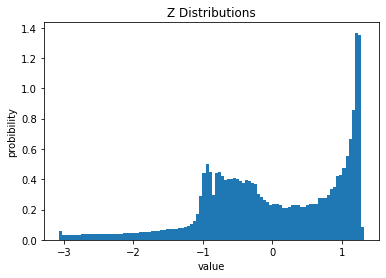

In [25]:
# Make histogram of values (either x,y,z,charge) from selected npy (train, val, test)
# Will need to change PLOT and DATA_SET_NAME to plot X-Y-Z-Q(charge) from training, val, or test
PLOT = 'Z'
DATA_SET_NAME = 'train'
index = PROJECTION.find(PLOT)

if index != -1:
    data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + DATA_SET_NAME + '_convert' + PROJECTION + '.npy')
    info = data[:,:,index].flatten()
    plt.hist(info, density=True, bins=100)
    plt.ylabel('probibility')
    plt.xlabel('value')
    plt.title(PLOT + ' Distributions')
    plt.show()
    # plt.savefig('data/'+ '.png', bbox_inches = 'tight') # uncomment to save
else:
    print('Value to plot is invalid, change PLOT')

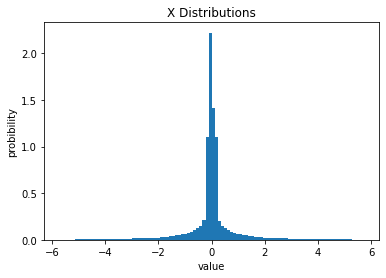

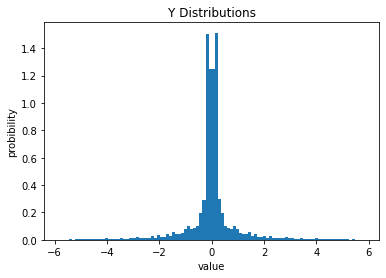

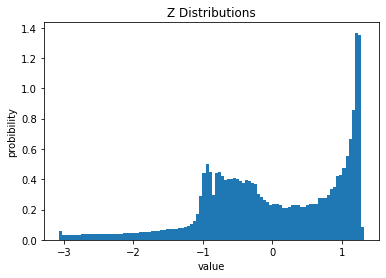

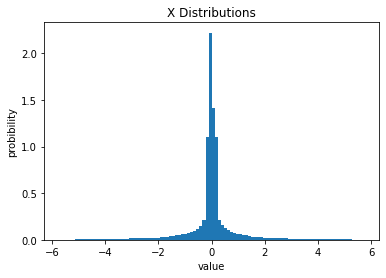

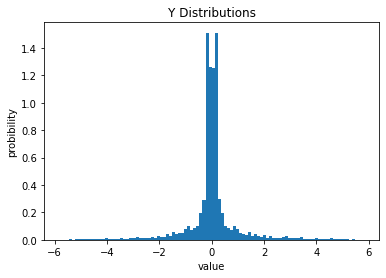

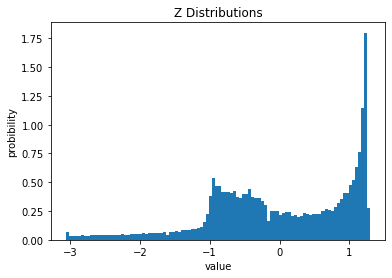

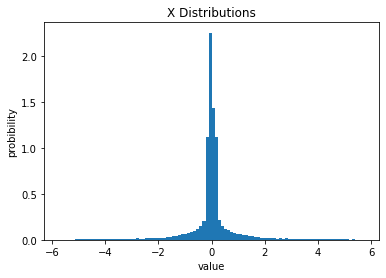

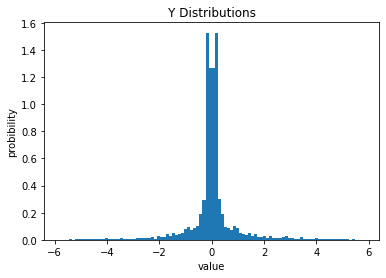

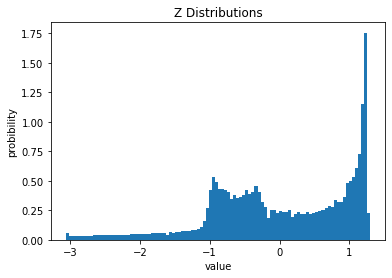

In [26]:
CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'
PLOT = ['X', 'Y','Z']
DATA_SET_NAME = ['train_convert','val_convert','test_convert']
for i in DATA_SET_NAME:
    for j in PLOT:
        index = PROJECTION.find(j)
        if index != -1:
            data = np.load('data/' +ISOTOPE+ '_size'+ str(sample_size) +i+ PROJECTION + '.npy')
            info = data[:,:,index].flatten()
            plt.hist(info, density=True, bins=100)
            plt.ylabel('probibility')
            plt.xlabel('value')
            plt.title(j + ' Distributions')
            plt.show()
            #plt.savefig('data/' +i+j+ '.png', bbox_inches = 'tight') 
        else:
            print('Value to plot is invalid, change PLOT')